In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import sqlite3 as sql
from sklearn.metrics import mean_absolute_error
from SQLQueries import BaseQuery

con = sql.connect('studentperformance.db')
curs = con.cursor()

BaseData = pd.read_sql(BaseQuery, con=con)

BaseData

,StudentID,SchoolID,SchoolName,Sex,Age,AddressType,FamilySize,ParentLivingStatus,Commute,ReasonForSchoolChoice,...,GuardianTwoID,FathersOccupationID,FathersOccupation,FathersEducationLevel,IsFatherPrimary,IsMotherPrimary,PrimaryGuardian,ExamOneGrade,ExamTwoGrade,ExamThreeGrade
0,0,1,GP,F,18,U,GT3,A,15-30 minutes,course,...,649,5,teacher,4,0,1,Mother,0,11,11
1,1,1,GP,F,17,U,GT3,T,<15 minutes,course,...,650,3,other,1,1,0,Father,9,11,11
2,2,1,GP,F,15,U,LE3,T,<15 minutes,other,...,651,3,other,1,0,1,Mother,12,13,12
3,3,1,GP,F,15,U,GT3,T,<15 minutes,home,...,652,4,services,2,0,1,Mother,14,14,14
4,4,1,GP,F,16,U,GT3,T,<15 minutes,home,...,653,3,other,3,1,0,Father,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,644,2,MS,F,19,R,GT3,T,<15 minutes,course,...,1293,3,other,3,0,1,Mother,10,11,10
645,645,2,MS,F,18,U,LE3,T,<15 minutes,course,...,1294,4,services,1,0,1,Mother,15,15,16
646,646,2,MS,F,18,U,GT3,T,15-30 minutes,course,...,1295,3,other,1,0,1,Mother,11,12,9
647,647,2,MS,M,17,U,LE3,T,15-30 minutes,course,...,1296,4,services,1,0,1,Mother,10,10,10


Remove Redundant columns

In [2]:
StudentData = BaseData.drop(columns=['SchoolName', 'GuardianOneID', 'GuardianTwoID', 'FathersOccupation', 'MothersOccupation', 'PrimaryGuardian'])

Get column names

In [3]:
for col in StudentData.columns:
    print(col)

StudentID
SchoolID
Sex
Age
AddressType
FamilySize
ParentLivingStatus
Commute
ReasonForSchoolChoice
TimeSpentStudying
FailureCount
EducationalSupport
ParentalSupport
ReceivesTutoring
ExtraCurricular
AttendedNursery
PlansOnHigherEducation
HasInternet
InRelationship
FamilyRelationshipRating
BusynessScale
SocialScore
WeekdayAlcoholConsumption
WeekendAlcoholConsumption
HealthScore
AbsenceCount
MothersOccupationID
MothersEducationLevel
FathersOccupationID
FathersEducationLevel
IsFatherPrimary
IsMotherPrimary
ExamOneGrade
ExamTwoGrade
ExamThreeGrade


Identifying Non-Numeric Columns

In [4]:
def NonNumeric(Frame):
    NonNumericColumns = []
    StudentDict = Frame.to_dict('records')
    for key in StudentDict[0].keys():
        #Attemps to cast number as integer if this raises an error the column will be added to the list of non-numeric columns
        try:
            StudentDict[0][key] = int(StudentDict[0][key])
        except ValueError:
            NonNumericColumns.append(key)
    return NonNumericColumns

NumericCols = NonNumeric(StudentData)
print(NumericCols)

['Sex', 'AddressType', 'FamilySize', 'ParentLivingStatus', 'Commute', 'ReasonForSchoolChoice', 'TimeSpentStudying', 'EducationalSupport', 'ParentalSupport', 'ReceivesTutoring', 'ExtraCurricular', 'AttendedNursery', 'PlansOnHigherEducation', 'HasInternet', 'InRelationship']


Performing Data Transformations

In [5]:
from DataModelling import *
TransformedData = StudentData.apply(IsMale, axis=1)
TransformedData = TransformedData.apply(HasRuralAddress, axis=1)
TransformedData = TransformedData.apply(FamilySizeGreaterThanThree, axis=1)
TransformedData = TransformedData.apply(ParentsSeperated, axis=1)
TransformedData = TransformedData.apply(CommuteTimeGreaterThan, axis=1)
TransformedData = TransformedData.apply(ChoseSchoolFor, axis=1)
TransformedData = TransformedData.apply(StudyHoursGreaterThan, axis=1)
TransformedData = TransformedData.apply(ConvertBoolToInt, axis=1)
TransformedData = TransformedData.drop(columns=['Sex', 'AddressType', 'FamilySize', 'ParentLivingStatus', 'Commute', 'ReasonForSchoolChoice', 'TimeSpentStudying'])
#Applying all functions from DataModelling.py to my data

#Sanity check, making sure all data has been transformed as expected
print(NonNumeric(TransformedData)) #Should result in empty list
TransformedData.head()

[]


,StudentID,SchoolID,Age,FailureCount,EducationalSupport,ParentalSupport,ReceivesTutoring,ExtraCurricular,AttendedNursery,PlansOnHigherEducation,...,ExamThreeGrade,IsMale,IsRuralAddress,FamilySizeGreaterThanThree,ParentsSeperated,CommuteTimeGreaterThan,ChoseSchoolForCourse,ChoseSchoolForReputation,ChoseSchoolForProximity,StudyHoursGreaterThan
0,0,1,18,0,1,0,0,0,1,1,...,11,0,0,1,1,15,1,0,0,2
1,1,1,17,0,0,1,0,0,0,1,...,11,0,0,1,0,0,1,0,0,2
2,2,1,15,0,1,0,0,0,1,1,...,12,0,0,0,0,0,0,0,0,2
3,3,1,15,0,0,1,0,1,1,1,...,14,0,0,1,0,0,0,0,1,5
4,4,1,16,0,0,1,0,0,1,1,...,13,0,0,1,0,0,0,0,1,2


Find Correlation Between Columns

array([], dtype=object)

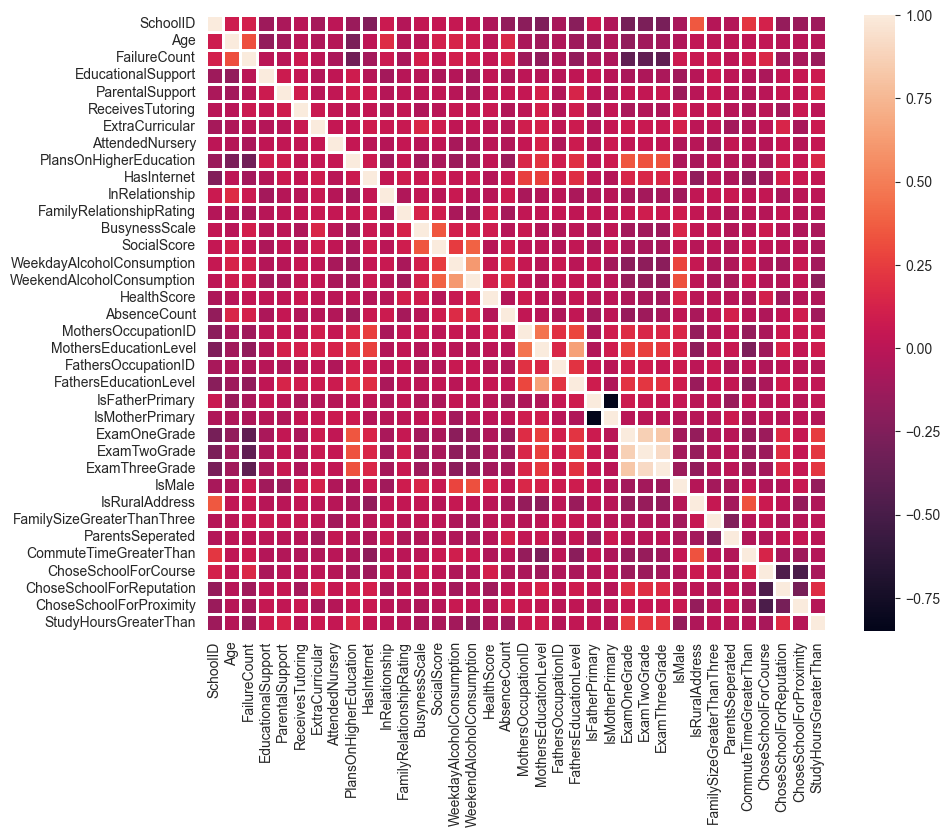

In [6]:
Correlation = TransformedData.drop(columns=['StudentID']).corr(numeric_only=True)
plt.figure(figsize = (10,8))
corr_heatmap = sns.heatmap(Correlation, linewidths=1)
corr_heatmap
#From This you can see that ExamTwoGrade has the greatest impact on ExamThreeGrade followed by ExamOneGrade
#The columns PlansOnHigherEducation also holds some weight on ExamThreeGrade as well as TheStudyHoursGreaterThan column showing students who studying more typically achieve a higher grade
def GetLowestCorrelationFields(CorrelationFilter=0):
    ExamThreeGradeCorrelation = Correlation['ExamThreeGrade'].reset_index().rename(columns={'ExamThreeGrade': 'Correlation', 'index':'Field'}) #Giving columns names and renaming ExamThreeGrade to be more descriptive of the data it now stores
    ExamThreeGradeCorrelation['AbsoluteCorrelation'] = abs(ExamThreeGradeCorrelation['Correlation']) #Finding the absolute value of the correlation each column has with
    ExamThreeGradeCorrelation.sort_values(['AbsoluteCorrelation']) #Sorting values in descending order to identify the columns with the least effect
    exclude = ExamThreeGradeCorrelation.loc[ExamThreeGradeCorrelation.AbsoluteCorrelation < CorrelationFilter] #Filters out fields with an absolute correlation greater than the CorrelationFilter value
    return exclude.Field.unique()

GetLowestCorrelationFields()

Splitting the data into train and test data

In [7]:
def SplitData(TransformedData, AddtionalColumnsToExclude=[]):
 ColsToExclude = ['StudentID', 'ExamThreeGrade'] #Columns to always exclude
 if len(AddtionalColumnsToExclude) != 0:
    for col in AddtionalColumnsToExclude: #Appends each col to the exclusion list
        ColsToExclude.append(col) #Allows for experimentation with exclude different number of columns to improve accuracy of model
 x = TransformedData.drop(columns=ColsToExclude) #What we are using to predict
 y = TransformedData['ExamThreeGrade'] #What we are predicting
 train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.2, random_state=1) #Splitting data 80% to train model and 20% to test the model
 return train_x, test_x, train_y, test_y


Training and Evaluating model ( Finding the most accurate model)

In [8]:
NumberOfTrees = [10,20,30,40,50,60,70,80,90,100]
filter_values = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]


def FitAndEvaluate(trees, train_x, test_x, train_y, test_y):
 ExamThreeGradeModel = RandomForestRegressor(n_estimators=trees, random_state=1) #Random state must be the same in all places where using the same model
 ExamThreeGradeModel.fit(train_x, train_y) #Training the model
 GradePredictions = ExamThreeGradeModel.predict(test_x) #Testing the model
 return mean_absolute_error(test_y, GradePredictions) #Calculating the average difference between actual and predicted

ErrorDicts = []
for trees in NumberOfTrees:
    #Loops through each amount of trees in the list
    for value in filter_values:
        #Loops through each filter value and trains the model using the given number of trees for each filter value
        ErrorDict = {} #Initialises a new dictionary each time which is empty
        ExcludeCols = GetLowestCorrelationFields(value)
        train_x, test_x, train_y, test_y = SplitData(TransformedData, ExcludeCols)
        ErrorDict['Trees'] = trees
        ErrorDict['Value'] = value
        ErrorDict['MAE'] = FitAndEvaluate(trees, train_x, test_x, train_y, test_y) #Evaluates MAE for specific tree amount and columns resulting from filter value
        ErrorDicts.append(ErrorDict) #Appending each dictionary to the list
    #Return the Mean Absolute error for each amount of trees in NumberOfTrees list to determine the best number of decision trees for the model

ErrorDataframe = pd.DataFrame(ErrorDicts)
LowestError = ErrorDataframe.sort_values(['MAE']).iloc[0] #Finding the combination with the lowest MAE (sort values ascending order than selects the first index)
print(LowestError)

HighestError = ErrorDataframe.sort_values(['MAE']).iloc[-1]  #Finding the combination with the highest MAE
print(HighestError)

#As you can see the lowest MAE occurs when you filter out all columns with a correlation lower than 0.25 and use 10 trees in your forest
#And the highest MAE occurs when you filter out only the columns with a correlation lower than 0.05 and use 10 trees
#We will then select the model with the lowest MAE to use for our application

Trees    10.00000
Value     0.25000
MAE       0.78847
Name: 5, dtype: float64
Trees    10.000000
Value     0.050000
MAE       0.943077
Name: 1, dtype: float64


Evaluating Model Accuracy

<Axes: title={'center': 'Predicted Vs Actual Grade'}, xlabel='Student', ylabel='Grade'>

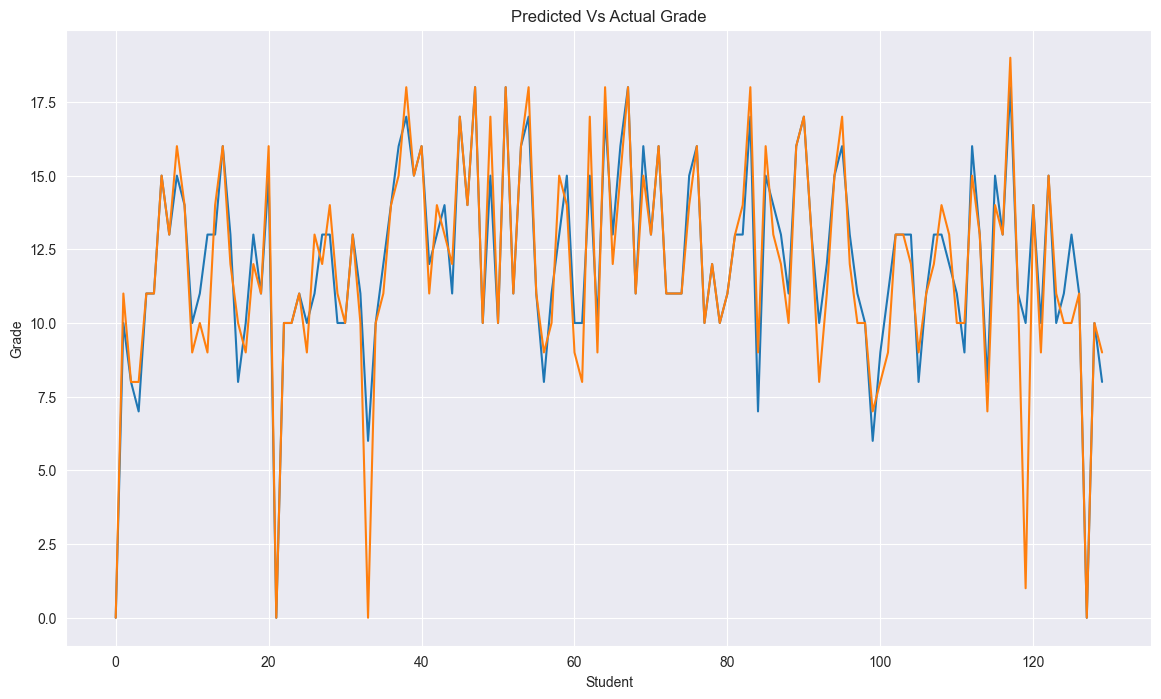

In [61]:
ExcludeCols = GetLowestCorrelationFields(0.25) #Excluding cols with an absolute correlation less than 0.25
train_x, test_x, train_y, test_y = SplitData(TransformedData, ExcludeCols)
GradePredictor = RandomForestRegressor(n_estimators=10, random_state=1) #Using what I found to be the most accurate model parameters
GradePredictor.fit(train_x, train_y)
GradePredictions = GradePredictor.predict(test_x)
RoundedPreds = [] #Empty list ot store the predictions rounded to 0 decimal places as a student cannot achieve a fraction of a grade
for i in GradePredictions:
    RoundedPreds.append(round(i, 0).item()) #Selects only the value rather than the data type as predictions are given as a numpy array which means it also states the values are of type int64 which is info I don't need

ActualGrades = list(test_y)

ActualVsPredictedDict = {'Student': [n for n in range(len(ActualGrades))], 'Predicted':RoundedPreds, 'Actual':ActualGrades} #list operation iterates through integers up to the length of the list and add them to a list
ActualVsPredictedDF = pd.DataFrame(ActualVsPredictedDict)

plt.figure(figsize = (14,8))
plt.ylabel('Grade')
plt.title('Predicted Vs Actual Grade')
sns.lineplot(ActualVsPredictedDF, x='Student', y='Predicted')
sns.lineplot(ActualVsPredictedDF, x='Student', y='Actual')